In [ ]:
pip install ultralytics opencv-python matplotlib albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'Sewer Defects.v1i.yolov9.zip', 'sample_data']


In [ ]:
!unzip -q "/content/Sewer Defects.v1i.yolov9.zip" -d /content/dataset

In [ ]:
print(os.listdir("/content/dataset"))

['README.roboflow.txt', 'train', 'data.yaml', 'test', 'README.dataset.txt', 'valid']


In [ ]:
dataset_path = "/content/dataset"

In [ ]:
import os
import cv2
import torch
import albumentations as A
from ultralytics import YOLO

torch.cuda.empty_cache()

In [ ]:
for split in ["train","valid","test"]:
    labels_path = f"{dataset_path}/{split}/labels"

    for file in os.listdir(labels_path):
        path = os.path.join(labels_path,file)
        if os.path.getsize(path) == 0:
            os.remove(path)

In [ ]:
image_folder = f"{dataset_path}/train/images"
label_folder = f"{dataset_path}/train/labels"

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.5)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

for img_file in os.listdir(image_folder):

    img_path = os.path.join(image_folder, img_file)
    label_path = os.path.join(label_folder, img_file.replace(".jpg",".txt"))

    image = cv2.imread(img_path)

    bboxes = []
    class_labels = []

    with open(label_path) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.split())
            bboxes.append([x,y,w,h])
            class_labels.append(int(cls))

    augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)

    new_name = "aug_" + img_file

    cv2.imwrite(os.path.join(image_folder,new_name), augmented["image"])

    with open(os.path.join(label_folder,new_name.replace(".jpg",".txt")),"w") as f:
        for box,cls in zip(augmented["bboxes"],class_labels):
            f.write(f"{cls} {' '.join(map(str,box))}\n")

    del image

In [ ]:
print(len(os.listdir(f"{dataset_path}/train/images")))

1368


In [ ]:
model = YOLO("yolov8m.pt")

model.train(
    data=f"{dataset_path}/data.yaml",

    epochs=150,
    patience=40,

    imgsz=640,
    batch=4,

    optimizer="SGD",
    lr0=0.01,
    momentum=0.937,

    augment=True,

    mosaic=1.0,
    mixup=0.1,

    scale=0.6,
    degrees=8,

    fliplr=0.5,

    plots=True
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=8, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=40, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782777455f40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(data=f"{dataset_path}/data.yaml")
print(metrics)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 567.1±103.0 MB/s, size: 17.7 KB)
val: Scanning /content/dataset/valid/labels.cache... 196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 58.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.0it/s 6.5s
                   all        196        510      0.558      0.473       0.45      0.186
              Buckling         34         40      0.388      0.475       0.37     0.0965
                 Crack         66        212      0.455      0.462       0.35      0.119
                Debris         32         37      0.753      0.541      0.557      0.278
                  Hole         10         12      0.537      0.293      0.312     0.0991
          Joint offset         40         93    

In [ ]:
model.predict(
    source=f"{dataset_path}/test/images",
    conf=0.25,
    save=True
)


image 1/98 /content/dataset/test/images/PI005120_f1320_jpg.rf.a749f62e768204e4472e5599b78fff1b.jpg: 640x640 1 Buckling, 3 Cracks, 37.3ms
image 2/98 /content/dataset/test/images/PI005120_f3480_jpg.rf.070872d89d05630be7084e644c1d7dab.jpg: 640x640 4 Cracks, 36.9ms
image 3/98 /content/dataset/test/images/PI005286_f2700_jpg.rf.9fdb62479bc6c7aee2605f9168212fe1.jpg: 640x640 1 Utility intrusion, 36.9ms
image 4/98 /content/dataset/test/images/PI005286_f3060_jpg.rf.cc77aecb3b85dabe64d2ba7e1abc1716.jpg: 640x640 1 Joint offset, 1 Utility intrusion, 30.6ms
image 5/98 /content/dataset/test/images/PI005286_f960_jpg.rf.8f1f01665d772c69b660346289227990.jpg: 640x640 1 Obstacle, 27.2ms
image 6/98 /content/dataset/test/images/PI005299_f11580_jpg.rf.238d47a4d318de38282c48d5693ebb11.jpg: 640x640 1 Joint offset, 27.3ms
image 7/98 /content/dataset/test/images/PI005299_f11700_jpg.rf.dde5053fe9c8ef26d7934756c18e0ba2.jpg: 640x640 1 Buckling, 1 Crack, 27.2ms
image 8/98 /content/dataset/test/images/PI005299_f120_

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Buckling', 1: 'Crack', 2: 'Debris', 3: 'Hole', 4: 'Joint offset', 5: 'Obstacle', 6: 'Utility intrusion'}
 obb: None
 orig_img: array([[[18,  7,  0],
         [11,  2,  0],
         [15,  6,  2],
         ...,
         [ 3,  5,  6],
         [ 0,  0,  1],
         [ 1,  1,  1]],
 
        [[17,  5,  0],
         [11,  1,  0],
         [12,  6,  1],
         ...,
         [24, 26, 27],
         [ 6,  5,  7],
         [ 7,  7,  7]],
 
        [[17,  6,  2],
         [ 9,  0,  0],
         [10,  5,  2],
         ...,
         [21, 25, 26],
         [ 0,  0,  1],
         [ 0,  0,  0]],
 
        ...,
 
        [[ 1,  2,  0],
         [ 0,  3,  1],
         [ 0,  1,  1],
         ...,
         [19, 24, 27],
         [ 0,  0,  3],
         [ 0,  2,  3]],
 
        [[ 1,  2,  0],
         [ 0,  3,  1],
         [ 0,  1,  1],
         ...,
   

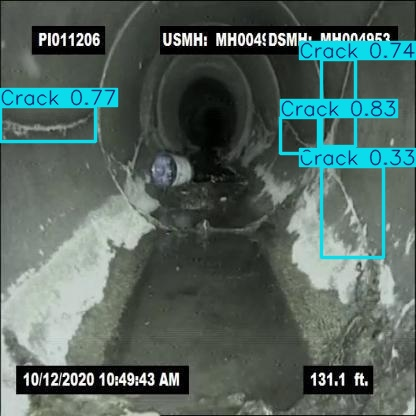

In [ ]:
from IPython.display import Image
import os

files = os.listdir("/content/runs/detect/predict")
Image("/content/runs/detect/predict/" + files[0])

In [ ]:
classes = ["Buckling","Crack","Debris","Hole","Joint offset","Obstacle","Utility intrusion"]

def get_severity(class_name, area, aspect_ratio):

    if class_name == "Crack":
        if aspect_ratio > 3:
            return "Severe"
        elif aspect_ratio > 2:
            return "Moderate"
        else:
            return "Minor"

    elif class_name == "Hole":
        if area > 0.1:
            return "Severe"
        elif area > 0.03:
            return "Moderate"
        else:
            return "Minor"

    elif class_name == "Debris":
        if area > 0.15:
            return "Severe"
        elif area > 0.05:
            return "Moderate"
        else:
            return "Minor"

    elif class_name == "Joint offset":
        return "Severe"

    elif class_name == "Utility intrusion":
        return "Severe" if area > 0.08 else "Moderate"

    elif class_name == "Buckling":
        return "Severe" if area > 0.1 else "Moderate"

    elif class_name == "Obstacle":
      if area > 0.12:
          return "Severe"
      elif area > 0.05:
          return "Moderate"
      else:
          return "Minor"

    else:
        return "Unknown"

In [ ]:
label_folder = f"{dataset_path}/test/labels"

for file in os.listdir(label_folder):

    with open(os.path.join(label_folder,file)) as f:

        for line in f.readlines():
            cls, x, y, w, h = map(float,line.split())

            class_name = classes[int(cls)]
            area = w * h
            aspect_ratio = w/h if h != 0 else 0

            severity = get_severity(class_name, area, aspect_ratio)

            print(f"{class_name} → {severity}")

Debris → Minor
Crack → Minor
Crack → Minor
Buckling → Moderate
Crack → Minor
Buckling → Moderate
Joint offset → Severe
Utility intrusion → Severe
Debris → Severe
Utility intrusion → Severe
Crack → Minor
Crack → Minor
Hole → Moderate
Joint offset → Severe
Joint offset → Severe
Debris → Severe
Crack → Minor
Buckling → Moderate
Utility intrusion → Moderate
Joint offset → Severe
Joint offset → Severe
Obstacle → Severe
Hole → Severe
Debris → Moderate
Crack → Minor
Crack → Moderate
Crack → Minor
Buckling → Moderate
Utility intrusion → Severe
Utility intrusion → Severe
Utility intrusion → Severe
Crack → Minor
Utility intrusion → Moderate
Crack → Minor
Crack → Minor
Crack → Minor
Crack → Minor
Joint offset → Severe
Debris → Moderate
Utility intrusion → Severe
Crack → Minor
Crack → Minor
Joint offset → Severe
Utility intrusion → Severe
Crack → Minor
Crack → Minor
Crack → Minor
Crack → Minor
Utility intrusion → Severe
Joint offset → Severe
Obstacle → Severe
Joint offset → Severe
Joint offset → S

In [ ]:
!zip -r final_results.zip /content/runs/detect

  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/val_batch1_pred.jpg (deflated 12%)
  adding: content/runs/detect/train/BoxPR_curve.png (deflated 10%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 18%)
  adding: content/runs/detect/train/BoxF1_curve.png (deflated 7%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 5%)
  adding: content/runs/detect/train/results.png (deflated 6%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 11%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 8%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 9%)
  adding: content/runs/detect/train/args.yaml (deflated 53%)
  adding: content/runs/detect/train/val_batch0_labels.jpg (deflated 15%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 13%)
  adding: content

In [ ]:
from google.colab import files
files.download("final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/runs/detect /content/drive/MyDrive/sewer_project_results

In [ ]:
import random
import os

test_path = f"{dataset_path}/test/images"

image_files = os.listdir(test_path)
img_file = random.choice(image_files)

img_path = os.path.join(test_path, img_file)

print("Selected Image:", img_file)

Selected Image: PI058868_f13620_jpg.rf.39e83494284fd343866f6ac3c80a4d62.jpg


In [ ]:
results = model(img_path)

img = cv2.imread(img_path)
h_img, w_img, _ = img.shape

for box in results[0].boxes:

    cls_id = int(box.cls[0])
    class_name = classes[cls_id]

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    w = (x2 - x1) / w_img
    h = (y2 - y1) / h_img

    severity = get_severity(class_name, w, h)

    print(f"Detected: {class_name} | Severity: {severity}")

    label = f"{class_name} ({severity})"

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, label, (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)


image 1/1 /content/dataset/test/images/PI058868_f13620_jpg.rf.39e83494284fd343866f6ac3c80a4d62.jpg: 640x640 1 Obstacle, 37.1ms
Speed: 4.0ms preprocess, 37.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Detected: Obstacle | Severity: Severe


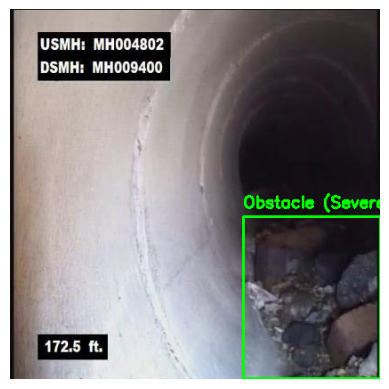

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

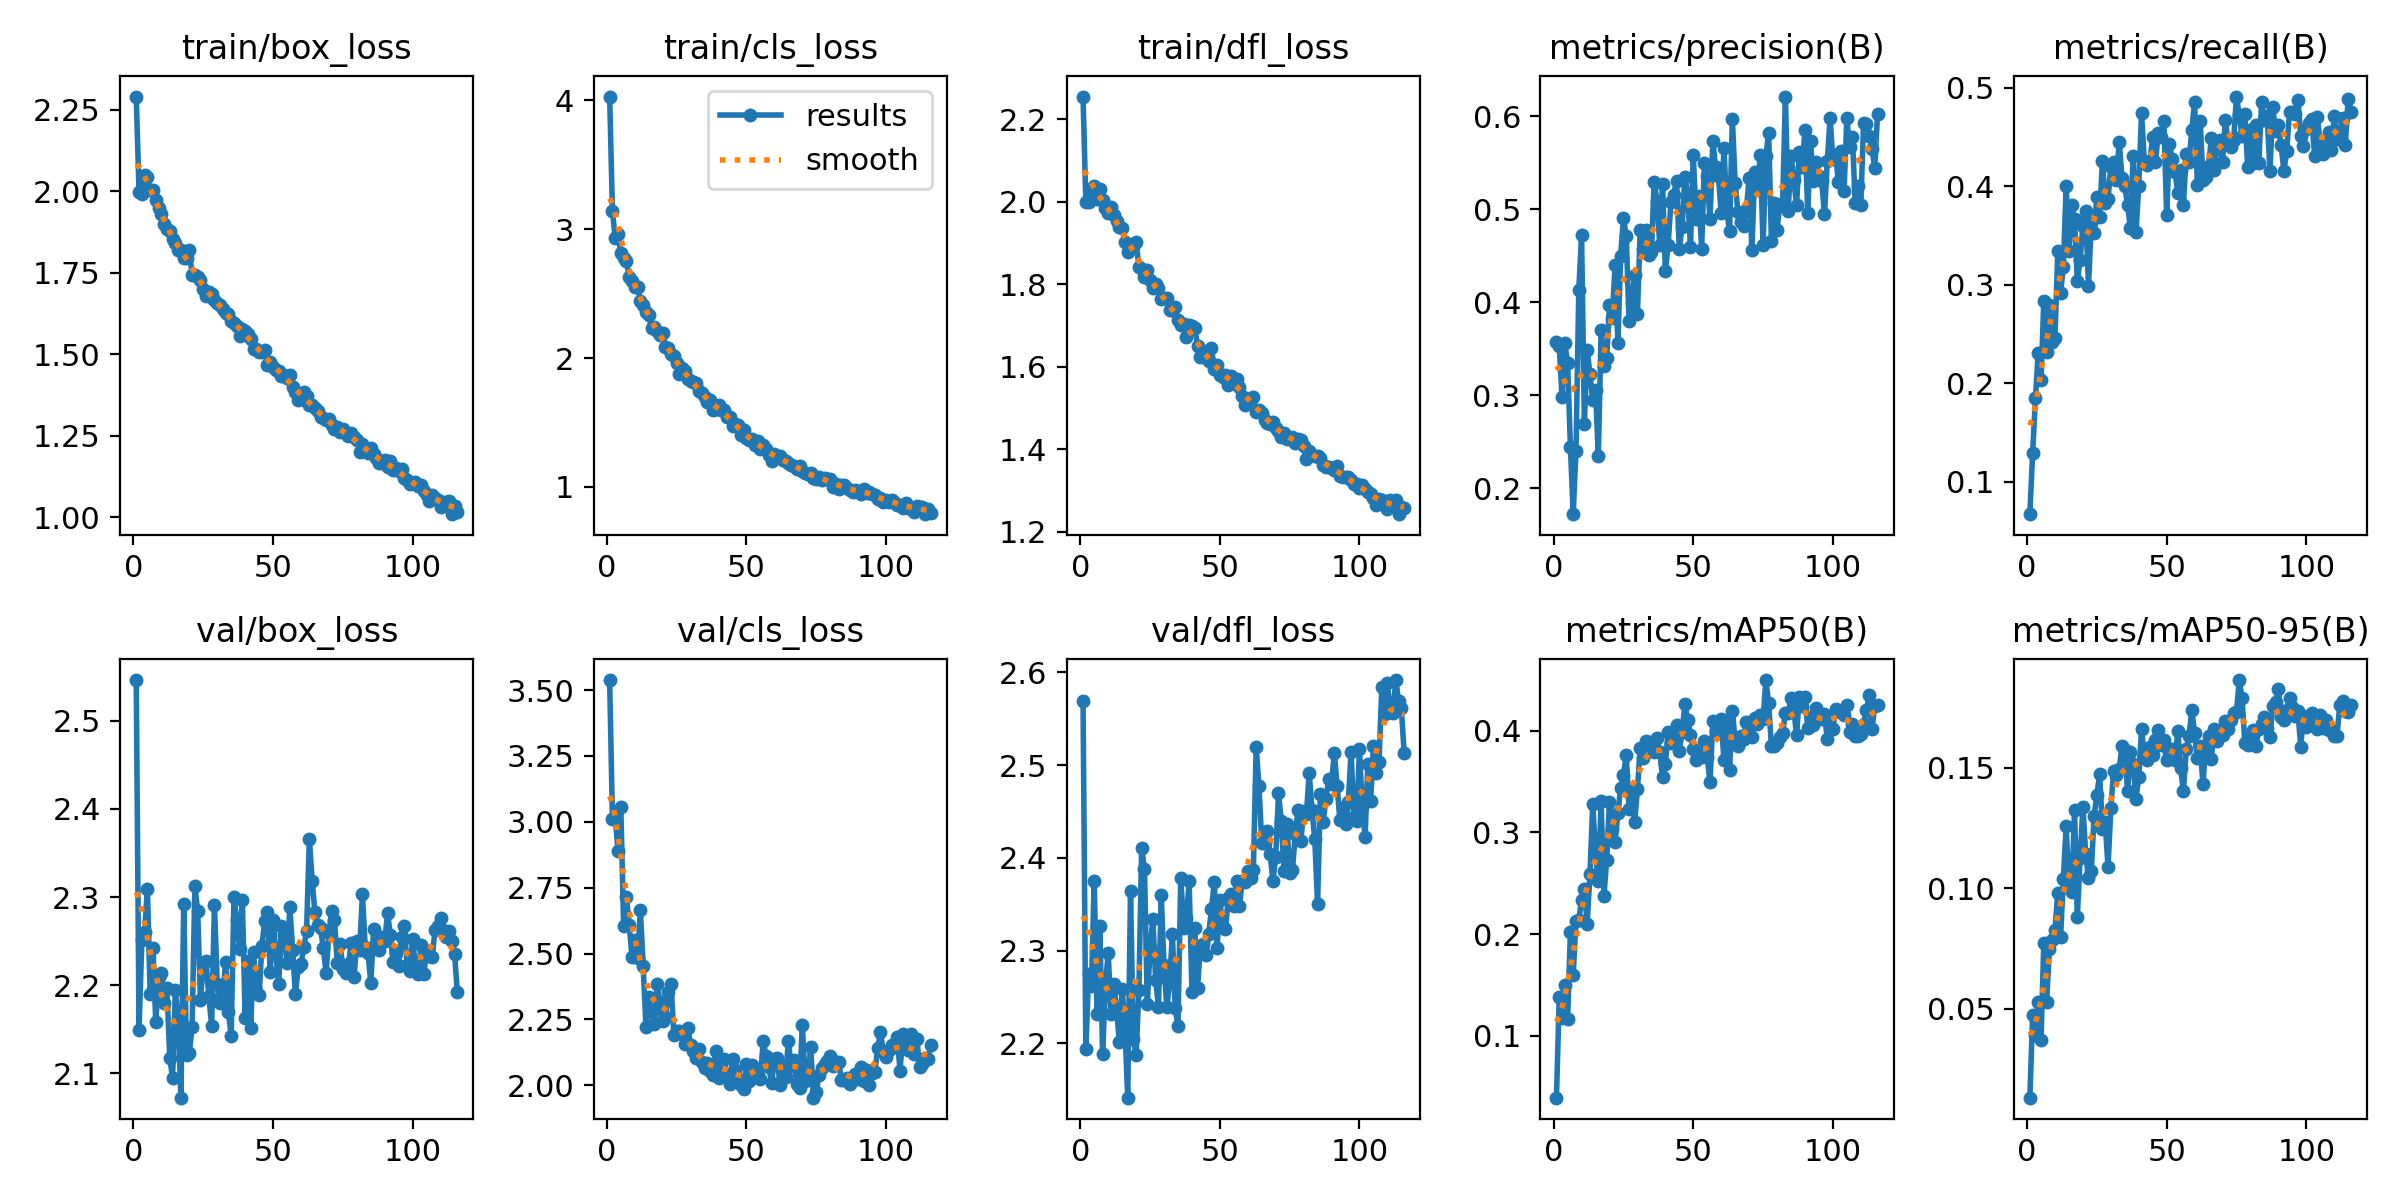

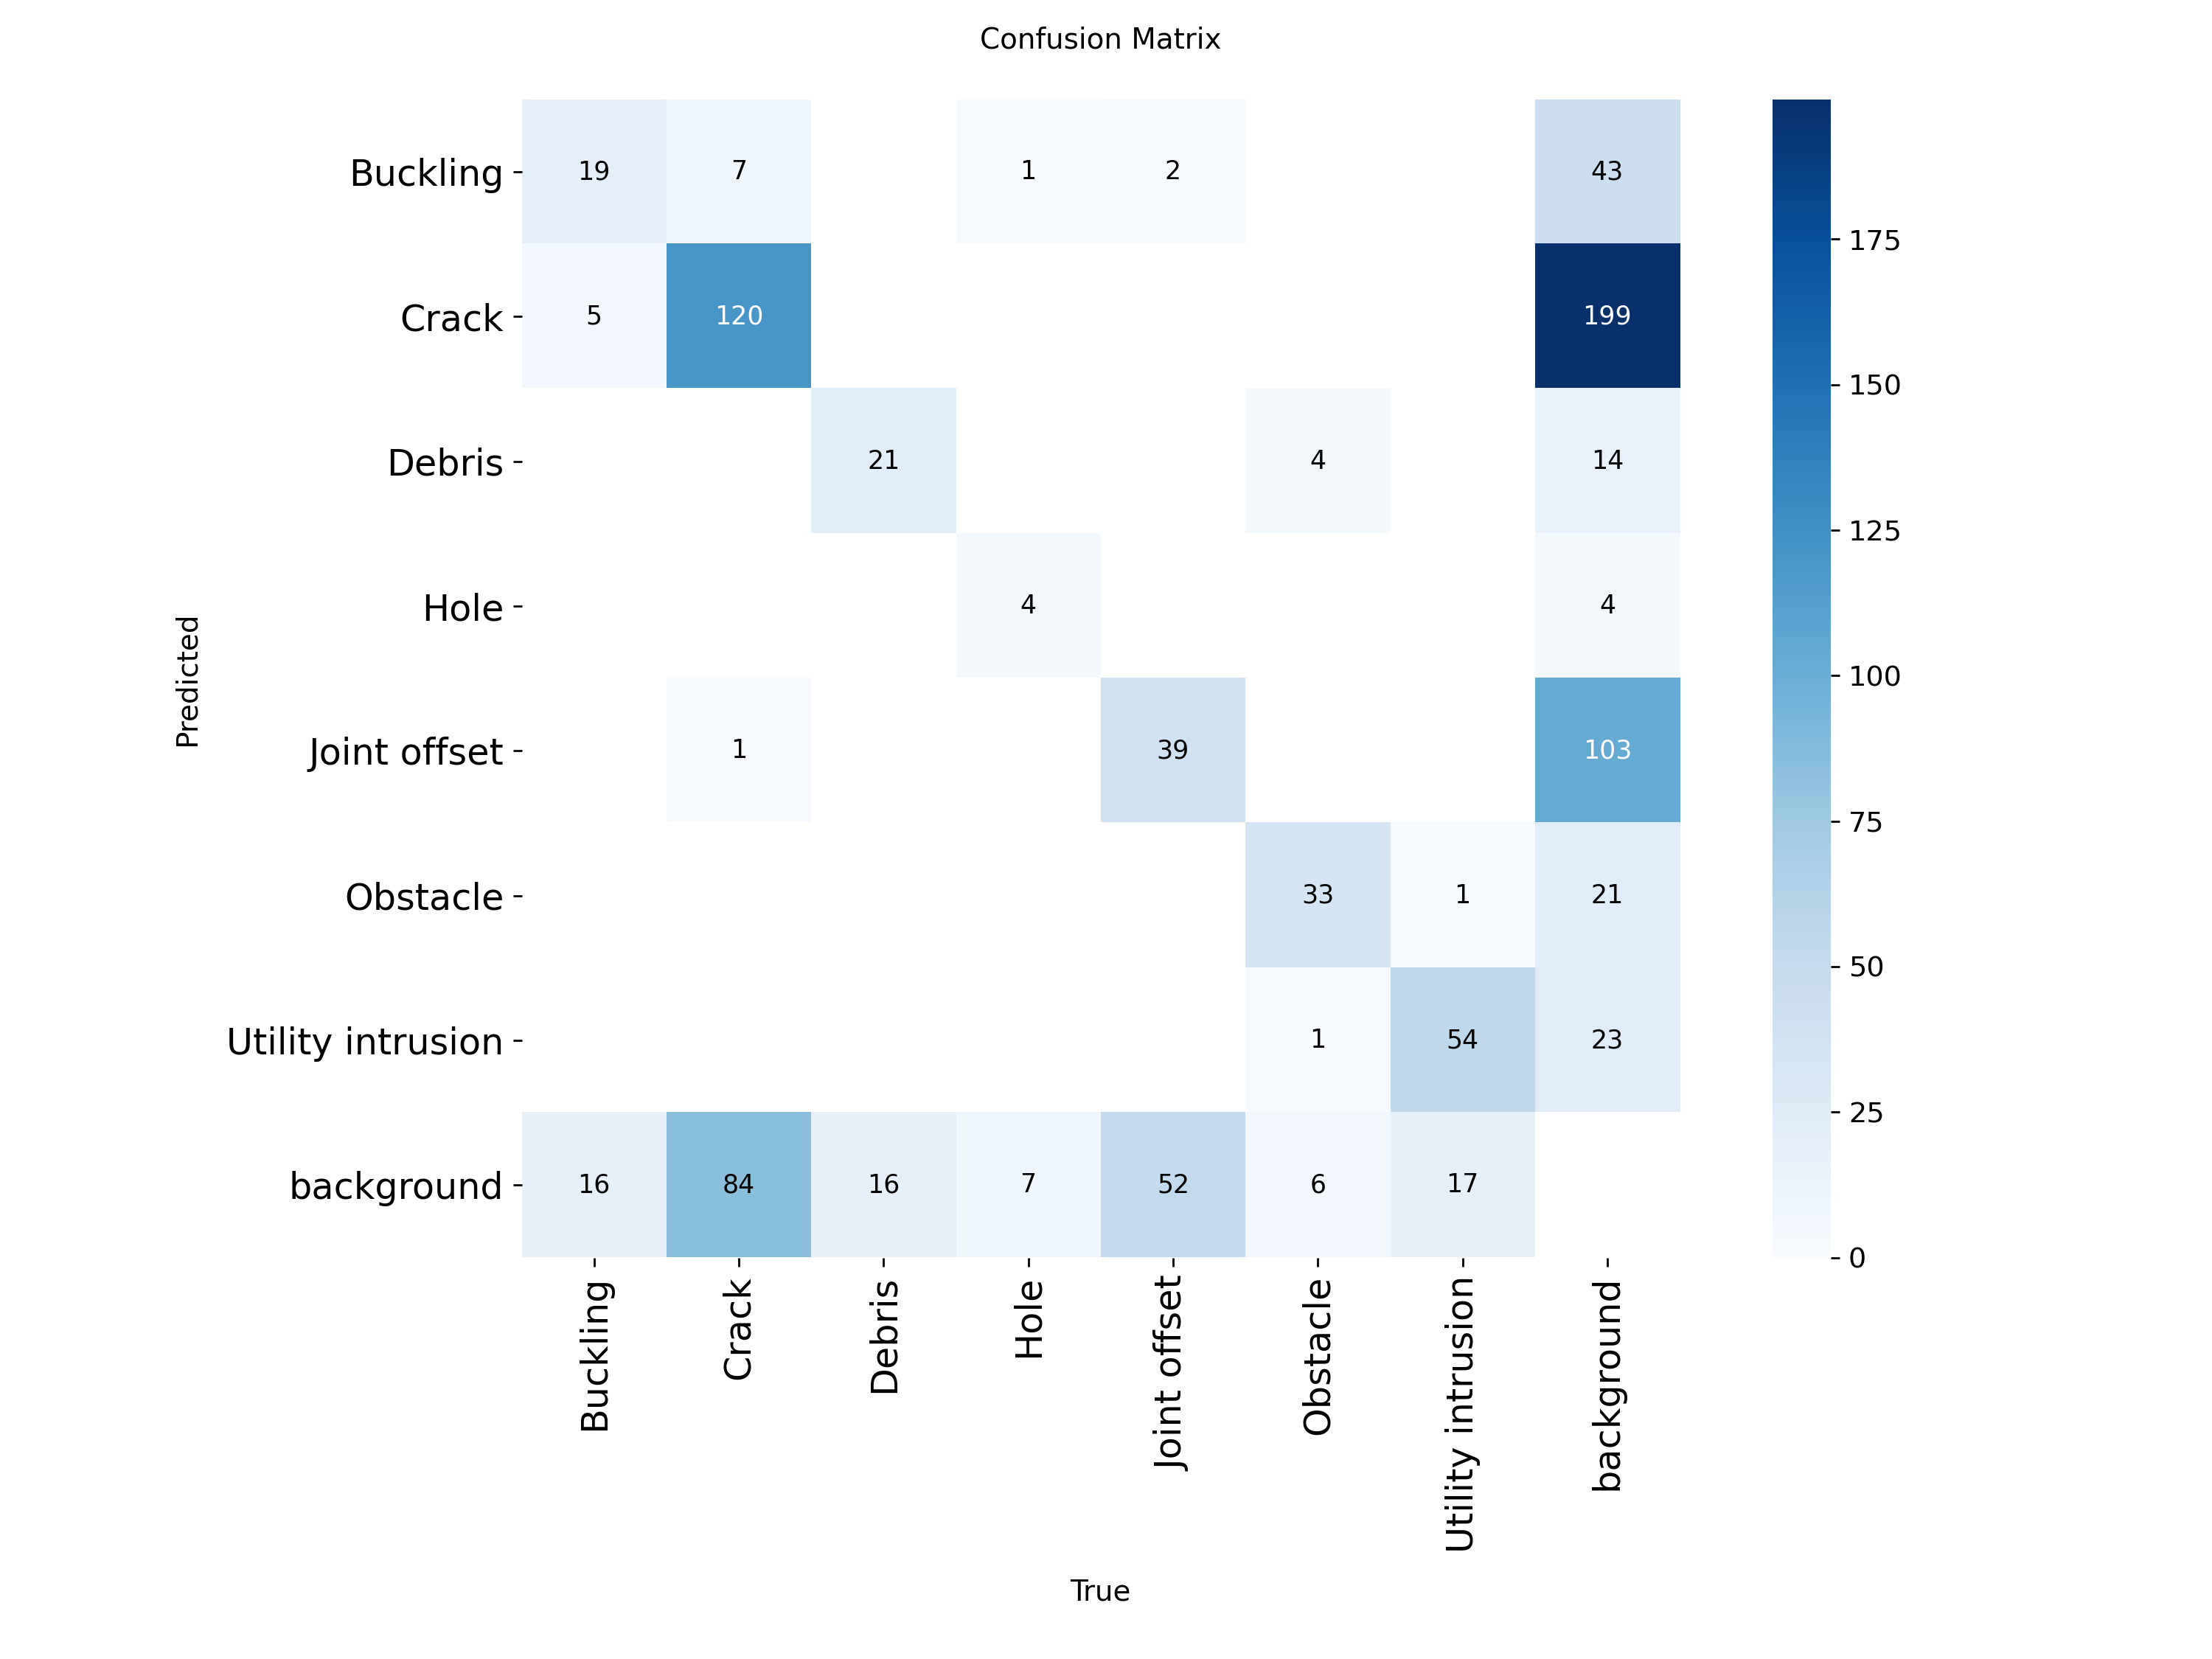

In [ ]:
from IPython.display import Image, display
import os

result_path = "/content/runs/detect/train"

files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for f in files:
    path = os.path.join(result_path, f)
    if os.path.exists(path):
        display(Image(filename=path))

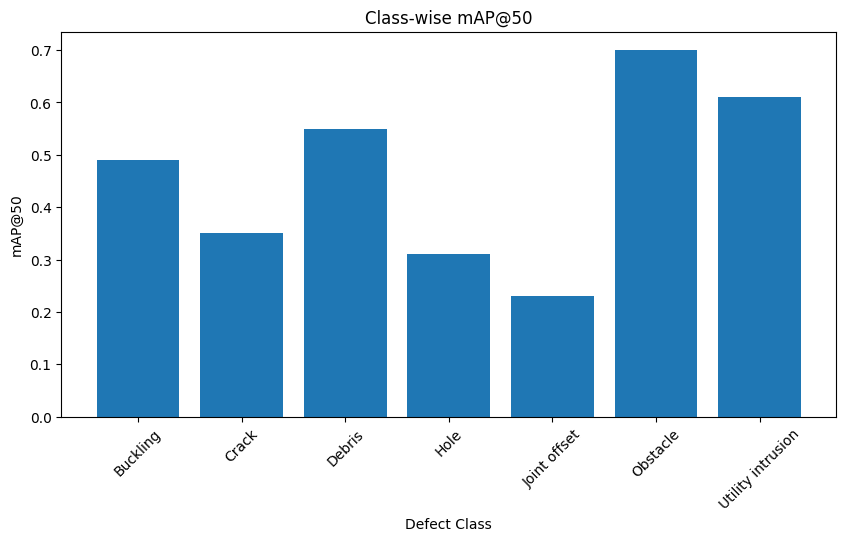

In [ ]:
import matplotlib.pyplot as plt

class_names = ["Buckling","Crack","Debris","Hole","Joint offset","Obstacle","Utility intrusion"]

# example values → replace with your actual output if needed
map50_values = [0.49, 0.35, 0.55, 0.31, 0.23, 0.70, 0.61]

plt.figure(figsize=(10,5))
plt.bar(class_names, map50_values)
plt.xticks(rotation=45)
plt.title("Class-wise mAP@50")
plt.xlabel("Defect Class")
plt.ylabel("mAP@50")
plt.show()

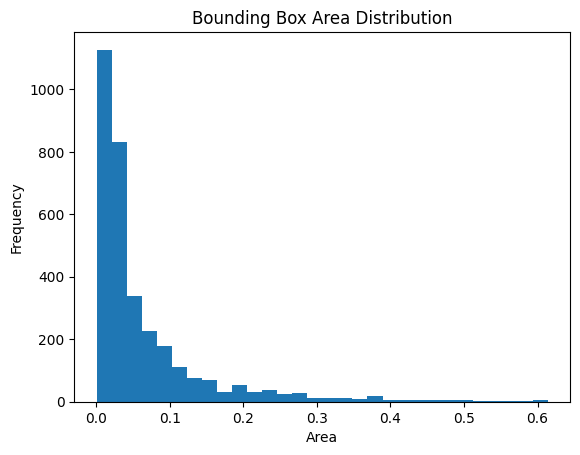

In [ ]:
import os

label_path = f"{dataset_path}/train/labels"

for file in os.listdir(label_path):
    with open(os.path.join(label_path,file)) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.split())
            areas.append(w*h)

plt.hist(areas, bins=30)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import os

dataset_path = "/content/dataset"
label_path = f"{dataset_path}/test/labels"

for file in os.listdir(label_path):
    with open(os.path.join(label_path,file)) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.split())
            print(cls)
severity_counts = {"Minor":0, "Moderate":0, "Severe":0}

label_path = "/content/test/labels"

for file in os.listdir(label_path):
    with open(os.path.join(label_path,file)) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float,line.split())

            area = w*h

            if area < 0.03:
                severity_counts["Minor"] += 1
            elif area < 0.1:
                severity_counts["Moderate"] += 1
            else:
                severity_counts["Severe"] += 1

plt.bar(severity_counts.keys(), severity_counts.values())
plt.title("Severity Distribution")
plt.show()


2.0
1.0
1.0
0.0
1.0
0.0
4.0
6.0
2.0
6.0
1.0
1.0
3.0
4.0
4.0
2.0
1.0
0.0
6.0
4.0
4.0
5.0
3.0
2.0
1.0
1.0
1.0
0.0
6.0
6.0
6.0
1.0
6.0
1.0
1.0
1.0
1.0
4.0
2.0
6.0
1.0
1.0
4.0
6.0
1.0
1.0
1.0
1.0
6.0
4.0
5.0
4.0
4.0
4.0
4.0
1.0
1.0
4.0
1.0
6.0
6.0
5.0
5.0
3.0
4.0
1.0
1.0
0.0
4.0
4.0
1.0
1.0
1.0
4.0
1.0
0.0
4.0
1.0
4.0
1.0
1.0
1.0
0.0
1.0
1.0
0.0
2.0
2.0
6.0
1.0
1.0
1.0
0.0
2.0
2.0
6.0
0.0
4.0
1.0
1.0
2.0
6.0
1.0
0.0
1.0
1.0
1.0
1.0
0.0
5.0
5.0
4.0
4.0
5.0
5.0
6.0
3.0
2.0
1.0
1.0
1.0
1.0
4.0
4.0
1.0
1.0
1.0
4.0
2.0
5.0
6.0
4.0
5.0
1.0
2.0
4.0
4.0
1.0
0.0
1.0
1.0
1.0
6.0
6.0
1.0
4.0
1.0
1.0
6.0
4.0
1.0
1.0
0.0
2.0
1.0
1.0
1.0
6.0
6.0
6.0
4.0
4.0
6.0
1.0
0.0
1.0
1.0
1.0
1.0
1.0
4.0
4.0
4.0
4.0
2.0
2.0
5.0
1.0
1.0
5.0
5.0
5.0
6.0
4.0
2.0
6.0
2.0
4.0
4.0
4.0
4.0
6.0
1.0
1.0
1.0
1.0
1.0
2.0
1.0
2.0
2.0
0.0
1.0
1.0
1.0
1.0
0.0
1.0
1.0
5.0
5.0
4.0
5.0
1.0
0.0
2.0
2.0
2.0


FileNotFoundError: [Errno 2] No such file or directory: '/content/test/labels'

Model loaded successfully from: /content/drive/MyDrive/sewer_project_results/train/weights/best.pt
Model classes: {0: 'Buckling', 1: 'Crack', 2: 'Debris', 3: 'Hole', 4: 'Joint offset', 5: 'Obstacle', 6: 'Utility intrusion'}
Using image folder: /content/drive/MyDrive/sewer_project_results/predict
Number of images: 98
Selected image: /content/drive/MyDrive/sewer_project_results/predict/PI014558_f3300_jpg.rf.9fad229de5e220733f19daff486cc5ff.jpg

image 1/1 /content/drive/MyDrive/sewer_project_results/predict/PI014558_f3300_jpg.rf.9fad229de5e220733f19daff486cc5ff.jpg: 640x640 1 Utility intrusion, 36.9ms
Speed: 13.7ms preprocess, 36.9ms inference, 50.6ms postprocess per image at shape (1, 3, 640, 640)


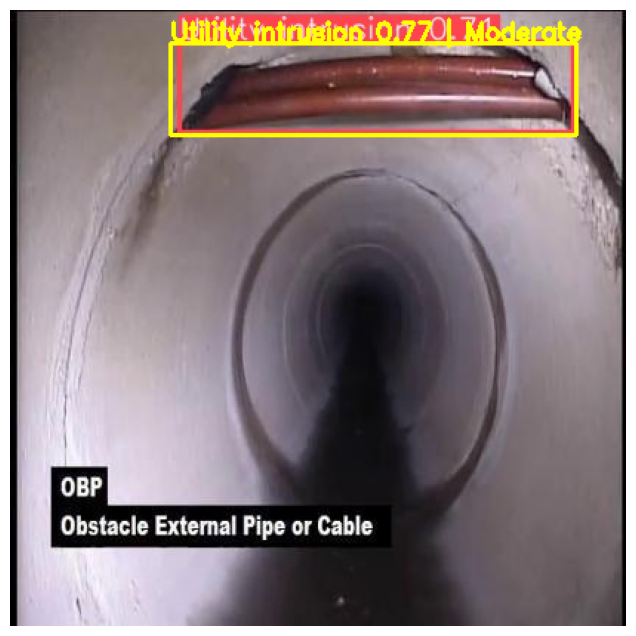

Saved in Colab: /content/severity_prediction.png
Saved in Drive: /content/drive/MyDrive/sewer_project_results/severity_prediction.png


In [ ]:
!pip install ultralytics -q

import os
import cv2
import random
import shutil
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==============================
# 1. LOAD BEST MODEL
# ==============================

model_path = "/content/drive/MyDrive/sewer_project_results/train/weights/best.pt"
model = YOLO(model_path)

print("Model loaded successfully from:", model_path)
print("Model classes:", model.names)

class_names = model.names

# ==============================
# 2. SEVERITY FUNCTION
# ==============================

def get_severity(class_name, width, height, conf):
    area = width * height
    aspect_ratio = width / height if height != 0 else 0

    cname = class_name.lower()

    if cname == "crack":
        if aspect_ratio > 4 or area > 0.08:
            return "Severe"
        elif aspect_ratio > 2 or area > 0.03:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "hole":
        if area > 0.08:
            return "Severe"
        elif area > 0.03:
            return "Moderate"
        else:
            return "Minor"

    elif cname in ["debris", "obstacle"]:
        if area > 0.10:
            return "Severe"
        elif area > 0.04:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "buckling":
        if area > 0.12:
            return "Severe"
        elif area > 0.05:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "utility intrusion":
        if area > 0.10:
            return "Severe"
        elif area > 0.04:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "joint offset":
        return "Severe"

    else:
        return "Unknown"

# ==============================
# 3. USE PREDICT FOLDER
# ==============================

test_img_dir = "/content/drive/MyDrive/sewer_project_results/predict"

image_files = [
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Using image folder:", test_img_dir)
print("Number of images:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError("No images found in predict folder.")

# ==============================
# 4. SELECT RANDOM IMAGE
# ==============================

img_file = random.choice(image_files)
img_path = os.path.join(test_img_dir, img_file)

print("Selected image:", img_path)

# ==============================
# 5. PREDICT
# ==============================

results = model.predict(img_path, conf=0.25)

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Could not read selected image.")

h, w, _ = img.shape

# ==============================
# 6. DRAW BOXES WITH SEVERITY
# ==============================

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        box_width_norm = (x2 - x1) / w
        box_height_norm = (y2 - y1) / h

        class_name = class_names[cls_id]
        severity = get_severity(class_name, box_width_norm, box_height_norm, conf)

        label = f"{class_name} {conf:.2f} | {severity}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)

        cv2.putText(
            img,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 255),
            2
        )

# ==============================
# 7. SAVE OUTPUT
# ==============================

save_path = "/content/severity_prediction.png"
cv2.imwrite(save_path, img)

drive_save_path = "/content/drive/MyDrive/sewer_project_results/severity_prediction.png"
shutil.copy(save_path, drive_save_path)

# ==============================
# 8. DISPLAY
# ==============================

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Saved in Colab:", save_path)
print("Saved in Drive:", drive_save_path)

Model loaded successfully from: /content/drive/MyDrive/sewer_project_results/train/weights/best.pt
Model classes: {0: 'Buckling', 1: 'Crack', 2: 'Debris', 3: 'Hole', 4: 'Joint offset', 5: 'Obstacle', 6: 'Utility intrusion'}
Total images found: 98
Selected images:
PI039436_f720_jpg.rf.49ebd838121c02d160a2beb94d18268f.jpg
PI054016_f480_jpg.rf.efb9a166fdfb342e06ad67f05051939d.jpg
PI052407_f12420_jpg.rf.cc9b065016f8670caa9f8054218d4166.jpg
PI010528_f14040_jpg.rf.547cda457b219c47fca5ab8fcfb5721b.jpg
PI014558_f9780_jpg.rf.a5b90e9732e7f59dc0975be8ca3737f2.jpg
PI012138_f780_jpg.rf.32da82b87de75cfcf9976e7f65b9446e.jpg


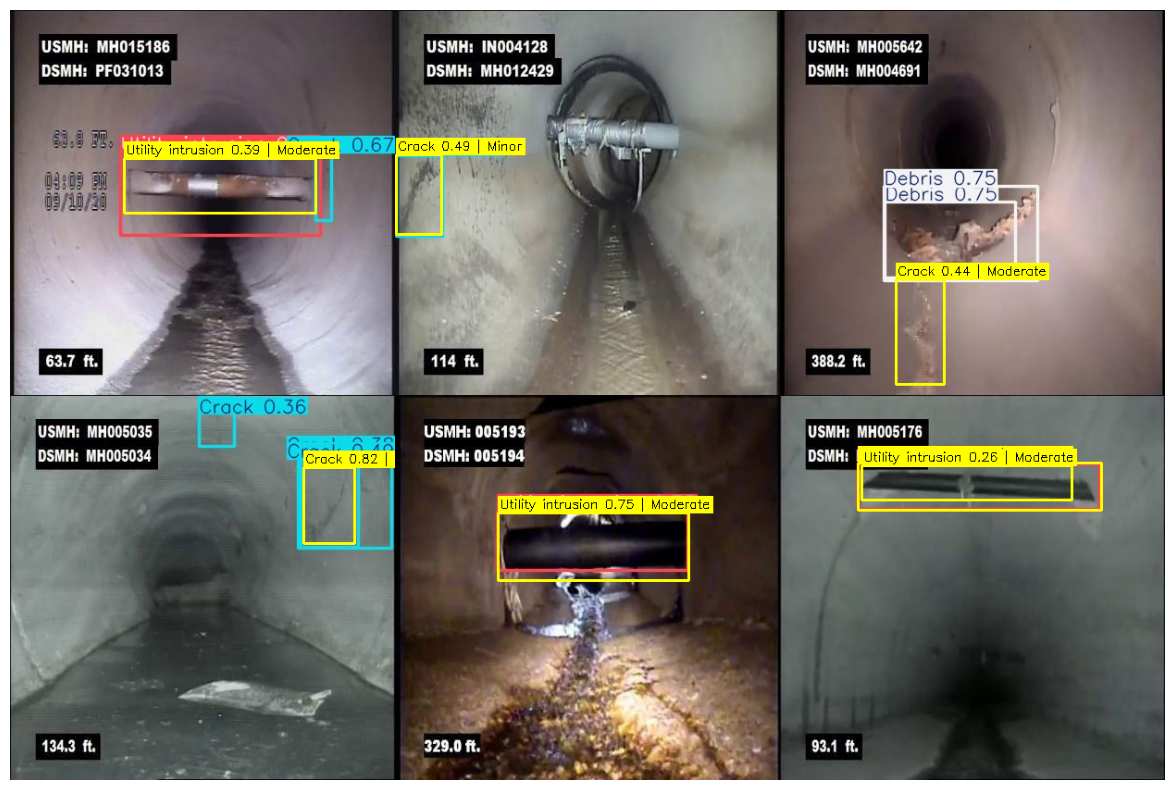

Saved severity grid in Colab: /content/severity_grid.png
Saved severity grid in Drive: /content/drive/MyDrive/sewer_project_results/severity_grid.png


In [ ]:
!pip install ultralytics -q

import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==============================
# 1. LOAD BEST MODEL
# ==============================

model_path = "/content/drive/MyDrive/sewer_project_results/train/weights/best.pt"
model = YOLO(model_path)

print("Model loaded successfully from:", model_path)
print("Model classes:", model.names)

class_names = model.names

# ==============================
# 2. SEVERITY FUNCTION
# ==============================

def get_severity(class_name, width, height, conf):
    area = width * height
    aspect_ratio = width / height if height != 0 else 0

    cname = class_name.lower()

    if cname == "crack":
        if aspect_ratio > 4 or area > 0.08:
            return "Severe"
        elif aspect_ratio > 2 or area > 0.03:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "hole":
        if area > 0.08:
            return "Severe"
        elif area > 0.03:
            return "Moderate"
        else:
            return "Minor"

    elif cname in ["debris", "obstacle"]:
        if area > 0.10:
            return "Severe"
        elif area > 0.04:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "buckling":
        if area > 0.12:
            return "Severe"
        elif area > 0.05:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "utility intrusion":
        if area > 0.10:
            return "Severe"
        elif area > 0.04:
            return "Moderate"
        else:
            return "Minor"

    elif cname == "joint offset":
        return "Severe"

    else:
        return "Unknown"

# ==============================
# 3. IMAGE FOLDER
# ==============================

input_dir = "/content/drive/MyDrive/sewer_project_results/predict"

image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError("No images found in predict folder.")

# Choose 6 random images
num_images = min(6, len(image_files))
selected_images = random.sample(image_files, num_images)

print("Selected images:")
for img in selected_images:
    print(img)

# ==============================
# 4. DRAW SEVERITY ON EACH IMAGE
# ==============================

processed_images = []

for img_file in selected_images:
    img_path = os.path.join(input_dir, img_file)

    results = model.predict(img_path, conf=0.25, verbose=False)

    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w, _ = img.shape

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            box_width_norm = (x2 - x1) / w
            box_height_norm = (y2 - y1) / h

            class_name = class_names[cls_id]
            severity = get_severity(class_name, box_width_norm, box_height_norm, conf)

            label = f"{class_name} {conf:.2f} | {severity}"

            # Bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)

            # Label background
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(img, (x1, max(y1 - th - 8, 0)), (x1 + tw + 4, y1), (0, 255, 255), -1)

            # Label text
            cv2.putText(
                img,
                label,
                (x1 + 2, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 0, 0),
                1
            )

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize all images same size for grid
    img_rgb = cv2.resize(img_rgb, (416, 416))

    processed_images.append(img_rgb)

# ==============================
# 5. CREATE 2 x 3 GRID
# ==============================

while len(processed_images) < 6:
    blank = np.ones((416, 416, 3), dtype=np.uint8) * 255
    processed_images.append(blank)

row1 = np.hstack(processed_images[:3])
row2 = np.hstack(processed_images[3:6])
grid = np.vstack([row1, row2])

# ==============================
# 6. SAVE GRID
# ==============================

save_path = "/content/severity_grid.png"
plt.figure(figsize=(12, 8))
plt.imshow(grid)
plt.axis("off")
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

drive_save_path = "/content/drive/MyDrive/sewer_project_results/severity_grid.png"
shutil.copy(save_path, drive_save_path)

print("Saved severity grid in Colab:", save_path)
print("Saved severity grid in Drive:", drive_save_path)